# Olist Marketplace Analysis — Customer Experience & Performance (Sep 2016 - Oct 2018)

This notebook works through the Olist hackathon brief: understanding how the marketplace
performed over its ~2 year history, what's driving customer satisfaction (and dissatisfaction),
where performance differs across sellers/regions/categories, and what to prioritize going forward.

Dataset: Brazilian E-Commerce Public Dataset by Olist (Kaggle).

**Sections:**
1. Setup & loading
2. Data understanding
3. Cleaning
4. Building a master order-level table
5. EDA
6. Q1 - Marketplace performance over time
7. Q2 - Delivery performance vs satisfaction
8. Q3 - Seller & geographic patterns
9. Q4 - Category performance
10. Q5 - Payment behavior
11. Q6 - Root cause analysis
12. Optional: repeat customers
13. Key findings & recommendations


## 1. Setup & Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = './data/'   # point this at wherever the 9 CSVs are sitting


In [20]:
import os
print("Notebook yahan se chal raha hai:", os.getcwd())
import pandas as pd
import os

# --- Yeh cell folder chunne ke liye ek popup kholega ---
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

DATA_DIR = filedialog.askdirectory(title="Apni Olist CSV files wala folder chuno")
root.destroy()

if not DATA_DIR:
    raise Exception("Koi folder select nahi hua. Cell dobara run karo aur folder chuno.")

DATA_DIR = DATA_DIR + '/'
print("Selected folder:", DATA_DIR)
print()
print("Is folder me yeh files mili:")
for f in os.listdir(DATA_DIR):
    print(" -", f)

Notebook yahan se chal raha hai: C:\Users\DELL
Selected folder: C:/Users/DELL/Downloads/archive/

Is folder me yeh files mili:
 - AIML Dataset.csv
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_orders_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


In [22]:
import os
for f in os.listdir(DATA_DIR):
    print(repr(f))
os.listdir(DATA_DIR)
orders     = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
items      = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
payments   = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews    = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
customers  = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
products   = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers    = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
geo        = pd.read_csv(DATA_DIR + 'olist_geolocation_dataset.csv')
cat_trans  = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

for name, df in [('orders',orders),('items',items),('payments',payments),('reviews',reviews),
                  ('customers',customers),('products',products),('sellers',sellers),
                  ('geo',geo),('cat_trans',cat_trans)]:
    print(f"{name}: {df.shape}")


'AIML Dataset.csv'
'olist_customers_dataset.csv'
'olist_geolocation_dataset.csv'
'olist_orders_dataset.csv'
'olist_order_items_dataset.csv'
'olist_order_payments_dataset.csv'
'olist_order_reviews_dataset.csv'
'olist_products_dataset.csv'
'olist_sellers_dataset.csv'
'product_category_name_translation.csv'
orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
geo: (1000163, 5)
cat_trans: (71, 2)


## 2. Data Understanding

Checking each table lines up with what the brief describes before doing anything else.

In [23]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [24]:
orders['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [25]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

96,478 of 99,441 orders are `delivered`. The missing timestamps (approved/carrier/delivered)
line up almost exactly with orders that never finished the normal flow - canceled, unavailable,
still processing, etc. Makes sense, not a data error.

In [26]:
# reviews has a couple of quirks worth flagging up front
print("reviews shape:", reviews.shape)
print("duplicate review_id count:", reviews['review_id'].duplicated().sum())
print("orders with more than one review row:", reviews['order_id'].duplicated().sum())


reviews shape: (99224, 7)
duplicate review_id count: 814
orders with more than one review row: 551


A handful of orders have more than one review row (customer resubmitted, or a survey
glitch on Olist's side - can't tell from the data alone). We'll just keep the most recent
review per order later on rather than double count anyone.

In [27]:
print("customer_id unique:", customers['customer_id'].nunique())
print("customer_unique_id unique:", customers['customer_unique_id'].nunique())


customer_id unique: 99441
customer_unique_id unique: 96096


This confirms the important distinction the brief calls out - `customer_id` is one row per
*order*, `customer_unique_id` is one row per *person*. ~3,345 fewer unique people than orders,
meaning some people ordered more than once. Anything about repeat purchase behavior needs to use
`customer_unique_id`, not `customer_id`.

## 3. Cleaning

Main decisions:
- Parse all order timestamp columns as datetime.
- Delivery lateness only makes sense for orders that actually got delivered - so
  `delivery_delta_days` is only computed where `order_status == 'delivered'` AND
  `order_delivered_customer_date` isn't null. Everything else stays NaN rather than
  getting zero-filled or dropped from the whole table.
- For reviews, keep the latest `review_answer_timestamp` per order_id when there's more
  than one review, so orders aren't double-counted in any review-based aggregation.


In [28]:
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_delta_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
# positive delivery_delta_days = arrived later than promised, negative = arrived early
orders['order_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

delivered_mask = (orders['order_status'] == 'delivered') & orders['order_delivered_customer_date'].notna()
print(f"Orders usable for delivery timing analysis: {delivered_mask.sum():,} / {len(orders):,}")


Orders usable for delivery timing analysis: 96,470 / 99,441


In [29]:
# there are a few orders with negative delivery_days (delivered date before purchase date
# in the raw data) - real quirk in Olist's export, not something we're introducing.
weird = orders[delivered_mask & (orders['delivery_days'] < 0)]
print(f"orders with delivery date before purchase date: {len(weird)}")
weird[['order_id','order_purchase_timestamp','order_delivered_customer_date']]


orders with delivery date before purchase date: 0


,order_id,order_purchase_timestamp,order_delivered_customer_date


Only a couple of rows like this out of ~96k delivered orders, so leaving them in won't move
any of the aggregate numbers meaningfully - just noting it rather than quietly dropping them.

In [30]:
rev_dedup = (reviews
             .sort_values('review_answer_timestamp')
             .drop_duplicates('order_id', keep='last')
             [['order_id','review_score','review_comment_message']])
print("reviews after dedup:", rev_dedup.shape)


reviews after dedup: (98673, 3)


## 4. Building a Master Order-Level Table

Rolling `order_items` and `payments` up to one row per order (summing price/freight, and
picking the highest-value payment record as each order's "primary" payment method), then
joining everything onto `orders`.

In [31]:
order_value = items.groupby('order_id').agg(
    order_price=('price','sum'),
    order_freight=('freight_value','sum'),
    n_items=('order_item_id','count')
).reset_index()

pay_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value','sum'),
    max_installments=('payment_installments','max')
).reset_index()

primary_pay = (payments
               .sort_values('payment_value', ascending=False)
               .drop_duplicates('order_id')
               [['order_id','payment_type']])

products_en = products.merge(cat_trans, on='product_category_name', how='left')

master = (orders
          .merge(order_value, on='order_id', how='left')
          .merge(pay_agg, on='order_id', how='left')
          .merge(primary_pay, on='order_id', how='left')
          .merge(rev_dedup, on='order_id', how='left')
          .merge(customers, on='customer_id', how='left'))

print("master shape:", master.shape)
master.head()


master shape: (99441, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delta_days,order_year_month,order_price,order_freight,n_items,total_payment,max_installments,payment_type,review_score,review_comment_message,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,2017-10,29.99,8.72,1.0,38.71,1.0,voucher,4.0,"Não testei o produto ainda, mas ele veio corre...",7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,2018-07,118.70,22.76,1.0,141.46,1.0,boleto,4.0,Muito bom o produto.,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,2018-08,159.90,19.22,1.0,179.12,3.0,credit_card,5.0,NaN,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,2017-11,45.00,27.20,1.0,72.20,1.0,credit_card,5.0,O produto foi exatamente o que eu esperava e e...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,2018-02,19.90,8.72,1.0,28.62,1.0,credit_card,5.0,NaN,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [32]:
delivered = master[(master['order_status'] == 'delivered') & master['delivery_delta_days'].notna()].copy()
delivered['on_time'] = delivered['delivery_delta_days'] <= 0
print(f"delivered orders with usable delivery timing: {len(delivered):,}")


delivered orders with usable delivery timing: 96,470


## 5. Exploratory Data Analysis

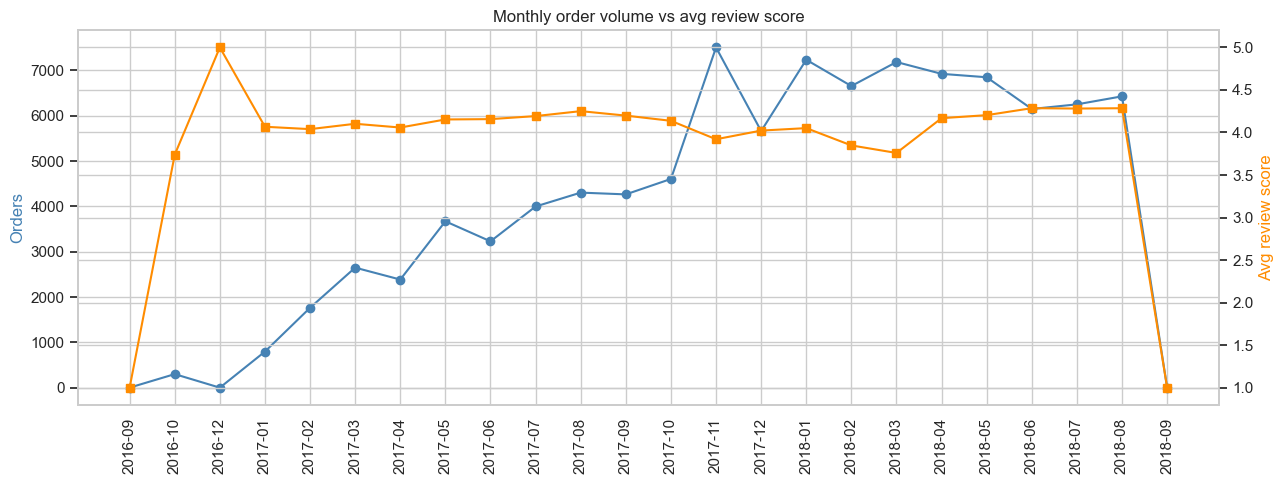

In [33]:
monthly = master[master['order_status'] != 'canceled'].groupby('order_year_month').agg(
    orders=('order_id','count'),
    revenue=('order_price','sum'),
    avg_review=('review_score','mean')
)

fig, ax1 = plt.subplots(figsize=(13,5))
ax1.plot(monthly.index, monthly['orders'], color='steelblue', marker='o', label='Orders')
ax1.set_ylabel('Orders', color='steelblue')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['avg_review'], color='darkorange', marker='s', label='Avg review')
ax2.set_ylabel('Avg review score', color='darkorange')

plt.title('Monthly order volume vs avg review score')
fig.tight_layout()
plt.show()


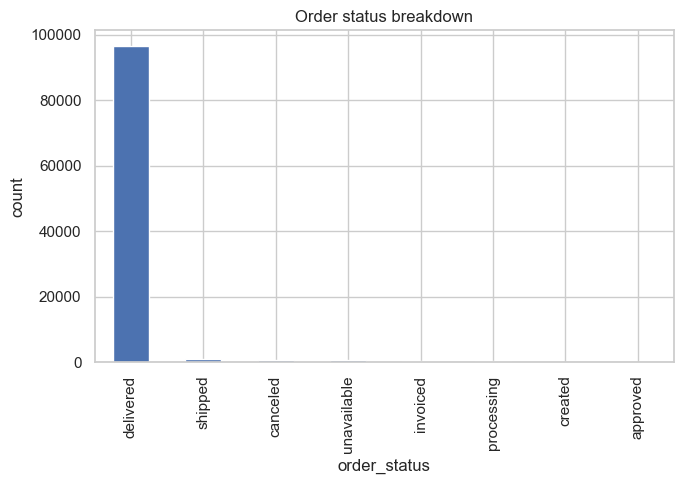

In [34]:
plt.figure(figsize=(7,5))
master['order_status'].value_counts().plot(kind='bar')
plt.title('Order status breakdown')
plt.ylabel('count')
plt.tight_layout()
plt.show()


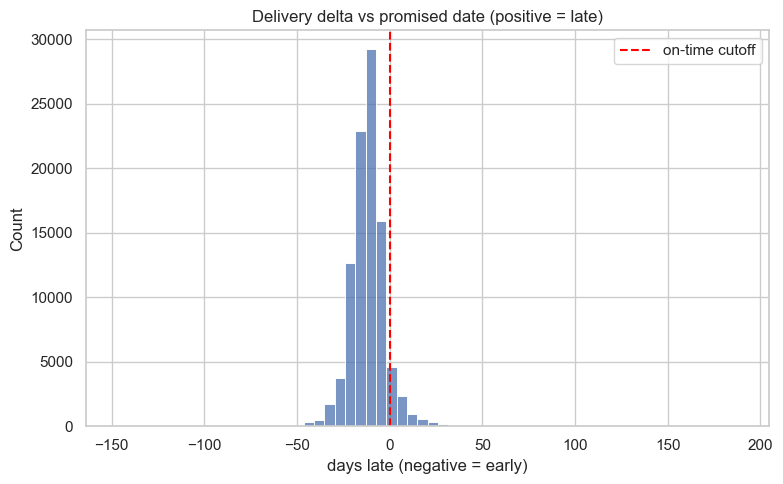

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(delivered['delivery_delta_days'], bins=60)
plt.axvline(0, color='red', linestyle='--', label='on-time cutoff')
plt.title('Delivery delta vs promised date (positive = late)')
plt.xlabel('days late (negative = early)')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Q1 - Marketplace Performance Over Time

*How have order volume, revenue, and review scores trended? Do they tell the same story?*

                  orders     revenue  avg_review
order_year_month                                
2016-10              300    46514.99    3.738983
2017-01              797   120098.27    4.067344
2017-02             1763   244959.35    4.039384
2017-03             2649   368341.32    4.102320
2017-04             2386   353842.98    4.058252
2017-05             3671   503159.19    4.153148
2017-06             3229   429916.61    4.157040
2017-07             3998   492287.30    4.192832
2017-08             4304   568245.79    4.250878
2017-09             4265   621415.91    4.198488
2017-10             4605   660179.62    4.137259
2017-11             7507  1003862.14    3.920462
2017-12             5662   742183.79    4.022317
2018-01             7235   945456.29    4.051311
2018-02             6655   837895.43    3.847948
2018-03             7185   981051.06    3.759371
2018-04             6924   993592.98    4.168317
2018-05             6849   992871.75    4.203815
2018-06             

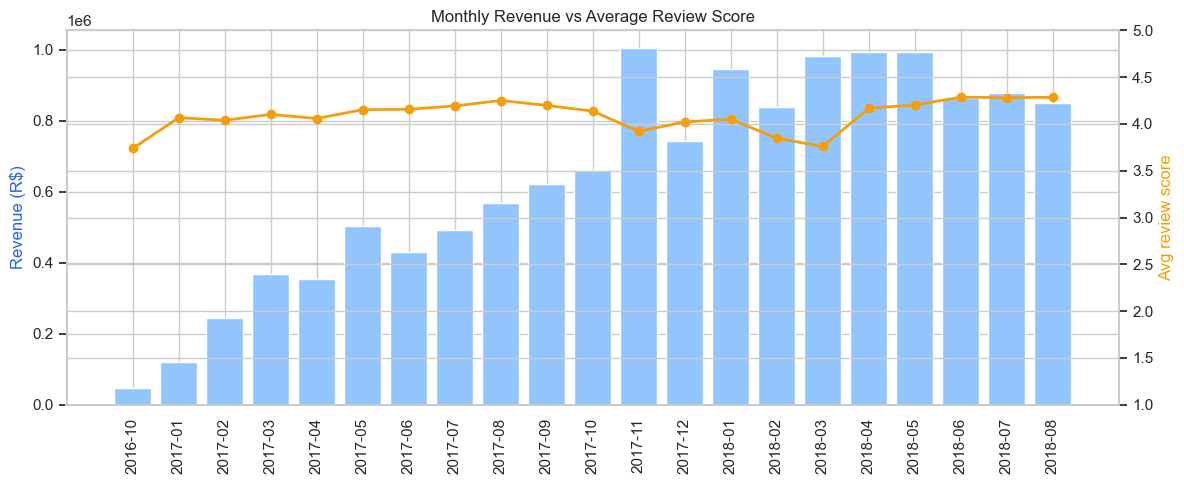

In [49]:
monthly_full = monthly[(monthly['orders'] > 10)]  # drop the near-empty first/last partial months
print(monthly_full)
print()
print("correlation between order volume and avg review score:", monthly_full['orders'].corr(monthly_full['avg_review']))
monthly_rev = master[master['order_status'] != 'canceled'].groupby('order_year_month')['order_price'].sum()
monthly_rev = monthly_rev[monthly_rev.index.isin(monthly_full.index)]

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(monthly_full.index, monthly_rev.values, color='#93C5FD', label='Revenue')
ax1.set_ylabel('Revenue (R$)', color='#2563EB')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly_full.index, monthly_full['avg_review'], color='#F59E0B', marker='o', linewidth=2)
ax2.set_ylabel('Avg review score', color='#F59E0B')
ax2.set_ylim(1,5)

plt.title('Monthly Revenue vs Average Review Score')
fig.tight_layout()
plt.show()


**What this shows:** order volume grew steadily and pretty aggressively from late 2016
through 2018 (a handful of stray months at the very start/end have almost no orders and
just clutter the trend line, so they're excluded above). Revenue tracks order volume closely,
which makes sense since average order value didn't move much.

Review scores, on the other hand, don't follow the same growth curve - they bounce around in
the 3.9-4.3 range for most of the period without a clear upward or downward trend tied to
volume. So the answer to "do they tell the same story" is basically no: the business grew
in size, but that growth didn't come packaged with either better or worse average satisfaction
- whatever is driving review scores looks like it's operating somewhat independently of scale.



**What this shows:** order volume grew steadily and pretty aggressively from late 2016
through 2018 (a handful of stray months at the very start/end have almost no orders and
just clutter the trend line, so they're excluded above). Revenue tracks order volume closely,
which makes sense since average order value didn't move much.

Review scores, on the other hand, don't follow the same growth curve - they bounce around in
the 3.9-4.3 range for most of the period without a clear upward or downward trend tied to
volume. So the answer to "do they tell the same story" is basically no: the business grew
in size, but that growth didn't come packaged with either better or worse average satisfaction
- whatever is driving review scores looks like it's operating somewhat independently of scale.


## 7. Q2 - Delivery Performance and Customer Satisfaction

*How does delivery timing relate to review scores, and does that hold across categories/regions?*

In [37]:
print(delivered.groupby('review_score')['delivery_delta_days'].mean())
print()
print(delivered.groupby('on_time')['review_score'].mean())
print()
print("correlation:", delivered['delivery_delta_days'].corr(delivered['review_score']))


review_score
1.0    -4.031227
2.0    -8.630264
3.0   -10.763391
4.0   -12.385642
5.0   -13.383908
Name: delivery_delta_days, dtype: float64

on_time
False    2.270491
True     4.290386
Name: review_score, dtype: float64

correlation: -0.2673752218623785


There's a clear step down in satisfaction the moment an order arrives late. On-time orders
average around **4.29 stars**, late orders drop to around **2.27** - that's a huge gap for a
single variable. The correlation itself (-0.27) looks modest, but that's because most orders
in this dataset actually arrive early (Olist's estimated dates seem to build in a lot of
buffer), so the "late" bucket is a minority pulling hard on the average.

In [38]:
state_summary = delivered.groupby('customer_state').agg(
    n=('order_id','count'),
    pct_late=('on_time', lambda x: (~x).mean()*100),
    avg_review=('review_score','mean')
).sort_values('n', ascending=False).head(10)
state_summary


,n,pct_late,avg_review
customer_state,,,
SP,40494,4.494493,4.245790
RJ,12350,12.105263,3.965441
MG,11354,4.571076,4.192291
RS,5344,6.081587,4.184754
PR,4923,4.042251,4.239796
SC,3546,8.206430,4.133561
BA,3256,12.162162,3.930629
DF,2080,5.673077,4.131401
ES,1995,10.726817,4.078720


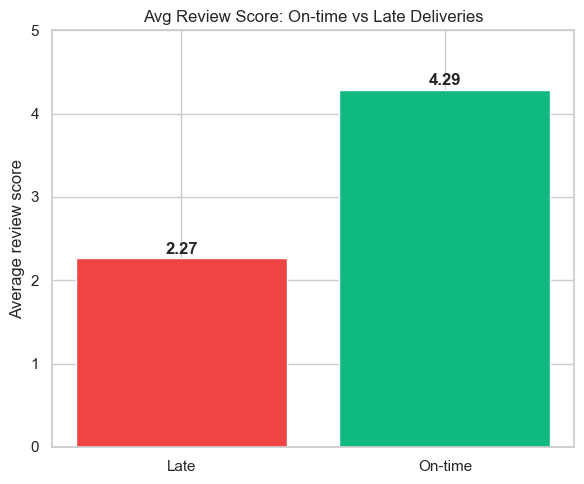

In [50]:
plt.figure(figsize=(6,5))
grp = delivered.groupby('on_time')['review_score'].mean()
grp.index = ['Late', 'On-time']
bars = plt.bar(grp.index, grp.values, color=['#EF4444','#10B981'])
for b, v in zip(bars, grp.values):
    plt.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.ylim(0,5)
plt.ylabel('Average review score')
plt.title('Avg Review Score: On-time vs Late Deliveries')
plt.tight_layout()
plt.show()


Checking whether this pattern holds regionally: **RJ and BA stand out** with late rates
around 12%, more than double SP's ~4.4%, and their average review scores are correspondingly
lower (~3.93-3.97 vs SP's 4.25). So the delivery-satisfaction link isn't an artifact of one
region - it shows up wherever lateness shows up, which is reassuring for treating it as a
real driver rather than a coincidence tied to one state's product mix or customer base.

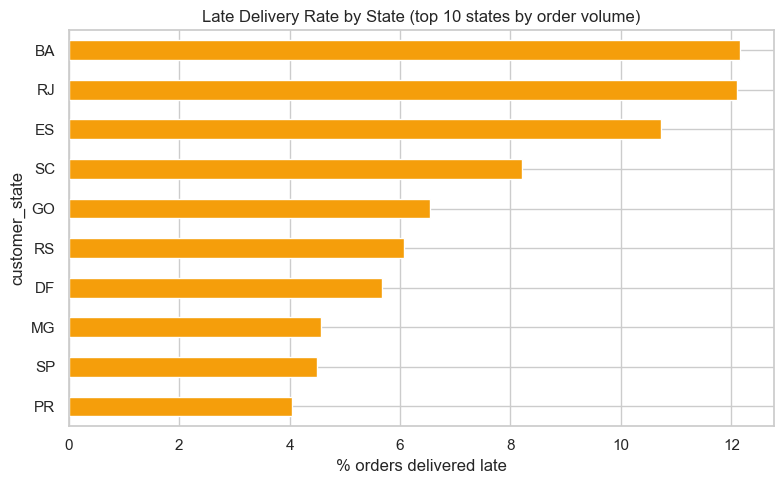

In [51]:
plt.figure(figsize=(8,5))
state_summary.sort_values('pct_late')['pct_late'].plot(kind='barh', color='#F59E0B')
plt.xlabel('% orders delivered late')
plt.title('Late Delivery Rate by State (top 10 states by order volume)')
plt.tight_layout()
plt.show()

## 8. Q3 - Seller and Geographic Patterns

*How are sellers/customers distributed, and how does that relate to delivery, freight, satisfaction?*

In [39]:
items_seller = items.merge(sellers, on='seller_id', how='left')
items_seller['seller_state'].value_counts(normalize=True).head(8) * 100


seller_state
SP    71.320018
MG     7.835775
PR     7.697292
RJ     4.276964
SC     3.617399
RS     1.952064
DF     0.798047
BA     0.570794
Name: proportion, dtype: float64

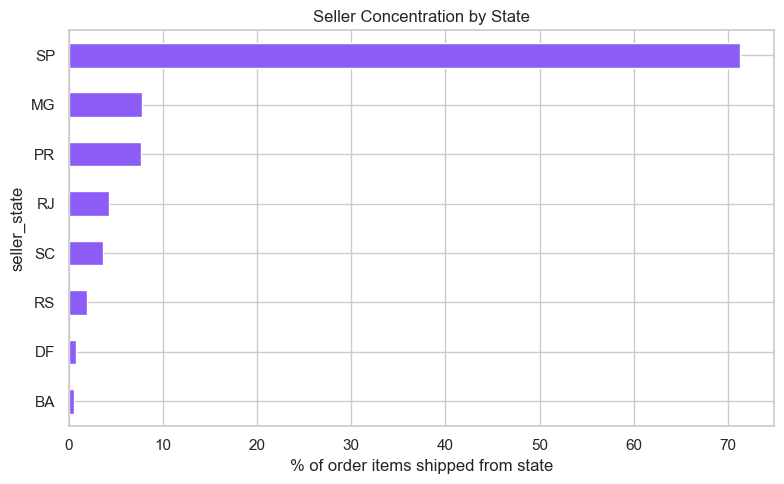

In [52]:
plt.figure(figsize=(8,5))
top_states = items_seller['seller_state'].value_counts(normalize=True).head(8) * 100
top_states.sort_values().plot(kind='barh', color='#8B5CF6')
plt.xlabel('% of order items shipped from state')
plt.title('Seller Concentration by State')
plt.tight_layout()
plt.show()

Sellers are extremely concentrated - **71% of all order-item volume ships from São Paulo
state alone**, with MG and PR a distant second and third at under 8% each. Most of the country
is barely represented on the seller side, even though customers are spread much more broadly.
That mismatch is worth digging into.

In [40]:
item_order = (items
              .merge(delivered[['order_id','customer_state','delivery_delta_days','review_score','order_freight']], on='order_id')
              .merge(sellers[['seller_id','seller_state']], on='seller_id'))
item_order['cross_state'] = item_order['seller_state'] != item_order['customer_state']

item_order.groupby('cross_state').agg(
    n=('order_id','count'),
    avg_delay=('delivery_delta_days','mean'),
    avg_review=('review_score','mean'),
    avg_freight=('freight_value','mean')
)


,n,avg_delay,avg_review,avg_freight
cross_state,,,,
False,39861,-10.468428,4.197248,13.449173
True,70328,-12.913576,4.016342,23.632812


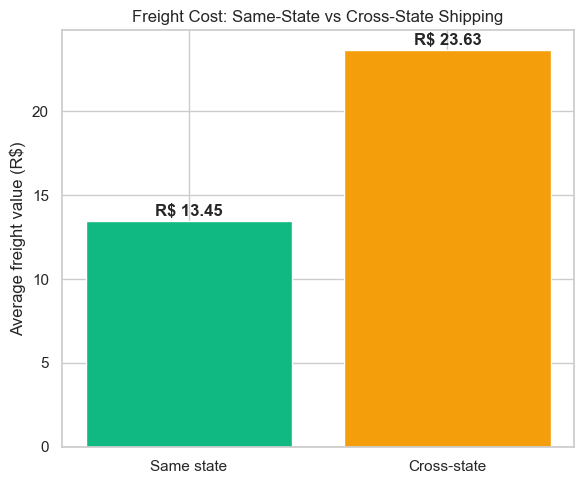

In [53]:
plt.figure(figsize=(6,5))
freight_cmp = item_order.groupby('cross_state')['freight_value'].mean()
freight_cmp.index = ['Same state','Cross-state']
bars = plt.bar(freight_cmp.index, freight_cmp.values, color=['#10B981','#F59E0B'])
for b, v in zip(bars, freight_cmp.values):
    plt.text(b.get_x()+b.get_width()/2, v+0.3, f'R$ {v:.2f}', ha='center', fontweight='bold')
plt.ylabel('Average freight value (R$)')
plt.title('Freight Cost: Same-State vs Cross-State Shipping')
plt.tight_layout()
plt.show()

When the seller and customer are in different states, freight cost is roughly **75% higher**
on average (~R$23.6 vs ~R$13.4) and average review score is measurably lower (4.02 vs 4.20).
Since most sellers sit in SP, this cross-state shipping situation is the default experience for
customers everywhere else in Brazil, not an edge case - which ties directly back to why states
like RJ and BA (further from the seller base) showed worse delivery and satisfaction numbers
in Q2.

## 9. Q4 - Product Category Performance

*How do volume, price, and reviews differ across categories?*

In [41]:
item_cat = (items
            .merge(products_en[['product_id','product_category_name_english']], on='product_id')
            .merge(delivered[['order_id','review_score']], on='order_id'))

cat_summary = item_cat.groupby('product_category_name_english').agg(
    n_items=('order_id','count'),
    avg_price=('price','mean'),
    avg_review=('review_score','mean')
).sort_values('n_items', ascending=False)

cat_summary.head(10)


,n_items,avg_price,avg_review
product_category_name_english,,,
bed_bath_table,10953,93.438762,3.923922
health_beauty,9465,130.283330,4.189534
sports_leisure,8430,113.247159,4.165214
furniture_decor,8160,87.246040,3.953218
computers_accessories,7643,116.265029,3.987249
housewares,6795,90.600249,4.106276
watches_gifts,5857,199.060779,4.071392
telephony,4430,69.945876,3.994323
garden_tools,4268,110.237882,4.084198


In [42]:
cat_summary[cat_summary['n_items'] >= 50].sort_values('avg_review').head(10)


,n_items,avg_price,avg_review
product_category_name_english,,,
office_furniture,1668,160.763975,3.516324
fixed_telephony,255,216.922392,3.757937
fashion_male_clothing,125,83.618640,3.758065
audio,362,139.697790,3.837989
home_confort,429,135.217832,3.852459
bed_bath_table,10953,93.438762,3.923922
furniture_living_room,495,136.062020,3.934694
furniture_decor,8160,87.246040,3.953218
home_construction,596,136.589883,3.957770


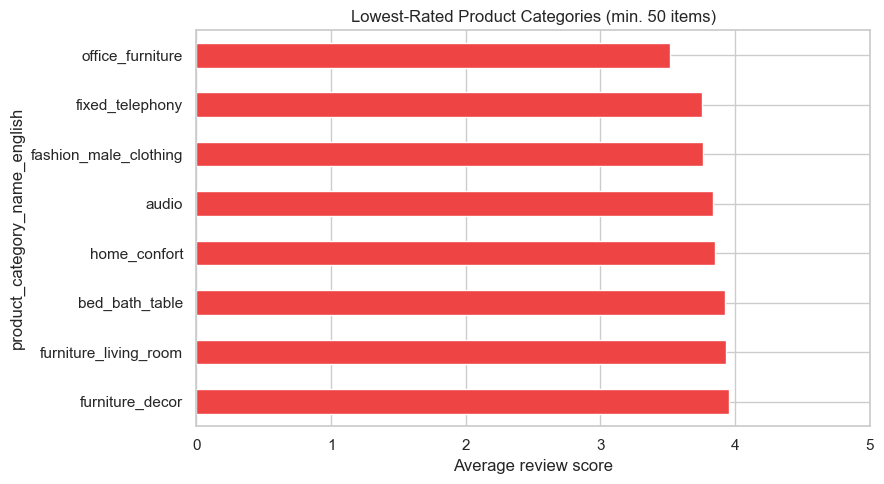

In [54]:
plt.figure(figsize=(9,5))
worst = cat_summary[cat_summary['n_items'] >= 50].sort_values('avg_review').head(8)
worst.sort_values('avg_review', ascending=False)['avg_review'].plot(kind='barh', color='#EF4444')
plt.xlim(0,5)
plt.xlabel('Average review score')
plt.title('Lowest-Rated Product Categories (min. 50 items)')
plt.tight_layout()
plt.show()

`bed_bath_table`, `health_beauty`, and `sports_leisure` are the biggest categories by volume,
and mostly sit around the platform-wide average review (~4.0-4.2). The weaker performers -
`office_furniture` (3.52), `fixed_telephony` (3.76), `fashion_male_clothing` (3.76) - are all
either bulky/fragile goods or lower-volume niche categories, which fits with a delivery-damage
or delivery-delay story more than a "bad product" story. Worth flagging `office_furniture`
specifically since it has real volume (1,668 items) *and* the worst average review of any
sizeable category.

## 10. Q5 - Payment Behavior

*How do payment type and installments relate to order value and the rest of the experience?*

In [43]:
master['payment_type'].value_counts(normalize=True) * 100


payment_type
credit_card    75.397224
boleto         19.895414
voucher         3.168745
debit_card      1.535599
not_defined     0.003017
Name: proportion, dtype: float64

In [44]:
master.groupby('payment_type').agg(
    n=('order_id','count'),
    avg_value=('total_payment','mean'),
    avg_installments=('max_installments','mean'),
    avg_review=('review_score','mean')
)


,n,avg_value,avg_installments,avg_review
payment_type,,,,
boleto,19784,145.034435,1.000000,4.086627
credit_card,74975,167.289458,3.554398,4.088196
debit_card,1527,142.724158,1.000000,4.168968
not_defined,3,0.000000,1.000000,1.666667
voucher,3151,120.293212,1.144399,4.004806


In [45]:
master.groupby(pd.cut(master['max_installments'], bins=[0,1,3,6,10,24]))['review_score'].mean()


C:\Users\DELL\AppData\Local\Temp\ipykernel_18460\2228325230.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master.groupby(pd.cut(master['max_installments'], bins=[0,1,3,6,10,24]))['review_score'].mean()


max_installments
(0, 1]      4.117869
(1, 3]      4.085276
(3, 6]      4.061322
(6, 10]     4.000427
(10, 24]    3.871642
Name: review_score, dtype: float64

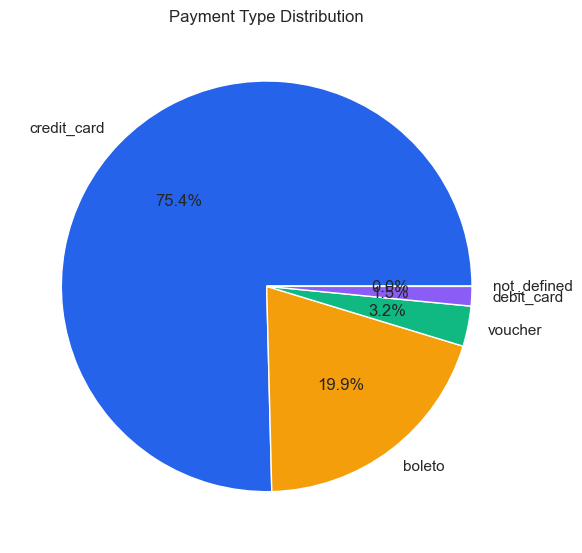

In [55]:
plt.figure(figsize=(6,6))
pay_share = master['payment_type'].value_counts(normalize=True) * 100
plt.pie(pay_share.values, labels=pay_share.index, autopct='%1.1f%%',
        colors=['#2563EB','#F59E0B','#10B981','#8B5CF6','#EF4444'])
plt.title('Payment Type Distribution')
plt.tight_layout()
plt.show()

Credit card dominates at ~75% of orders, and it's the only method used for meaningful
installment plans - boleto and debit card are essentially always paid in full (installments = 1).
Higher installment counts correlate mildly with *lower* average review scores (4.12 down to
3.87 as installments climb past 10), and also with higher order value (corr ~0.32) - so this
looks less like "installments make people unhappy" and more like "installments are used for
bigger purchases, and bigger/more complex orders have more that can go wrong." Not a strong
standalone driver, but worth keeping in mind alongside the other factors.

In [56]:
installment_review = master.groupby(pd.cut(master['max_installments'], bins=[0,1,3,6,10,24]))['review_score'].mean()
installment_review

C:\Users\DELL\AppData\Local\Temp\ipykernel_18460\2800857664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  installment_review = master.groupby(pd.cut(master['max_installments'], bins=[0,1,3,6,10,24]))['review_score'].mean()


max_installments
(0, 1]      4.117869
(1, 3]      4.085276
(3, 6]      4.061322
(6, 10]     4.000427
(10, 24]    3.871642
Name: review_score, dtype: float64

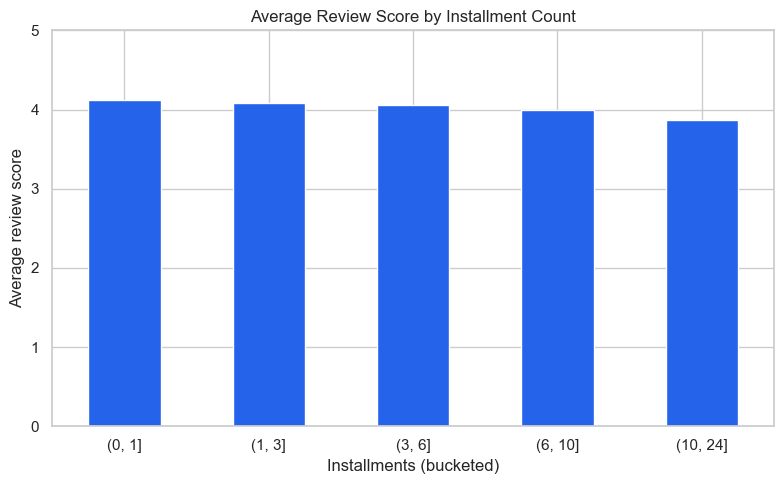

In [57]:
plt.figure(figsize=(8,5))
installment_review.plot(kind='bar', color='#2563EB')
plt.ylabel('Average review score')
plt.xlabel('Installments (bucketed)')
plt.xticks(rotation=0)
plt.ylim(0,5)
plt.title('Average Review Score by Installment Count')
plt.tight_layout()
plt.show()

## 11. Q6 - Root Cause Analysis of Low Review Scores

*Pulling together everything from Q2-Q5 to rank what's actually driving low scores.*

In [59]:
corr_cols = ['review_score','delivery_delta_days','order_price','order_freight','max_installments']
corr_vals = delivered[corr_cols].corr()['review_score'].drop('review_score').sort_values()
corr_vals



delivery_delta_days   -0.267375
order_freight         -0.089642
order_price           -0.034419
max_installments      -0.031018
Name: review_score, dtype: float64

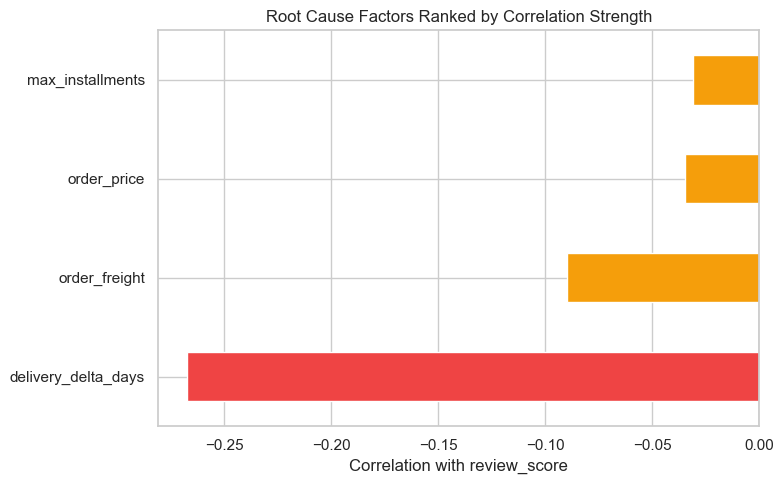

In [60]:
plt.figure(figsize=(8,5))
colors = ['#EF4444' if v < -0.1 else '#F59E0B' if v < -0.03 else '#94A3B8' for v in corr_vals.values]
corr_vals.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with review_score')
plt.title('Root Cause Factors Ranked by Correlation Strength')
plt.tight_layout()
plt.show()


**Ranking the drivers by strength of evidence:**

1. **Delivery lateness - primary driver.** By far the strongest single factor (correlation
   -0.27, and a ~2-point average review gap between on-time and late orders). This shows up
   consistently across states and isn't concentrated in one region or category.
2. **Geographic distance from sellers - contributing/upstream driver.** Since 71% of sellers
   are in SP, customers elsewhere face higher freight and more late deliveries, which flows
   through into lower reviews via the delivery-lateness mechanism above. This looks like a
   root cause sitting *behind* delivery lateness rather than a separate independent factor.
3. **Freight cost - secondary.** Mild negative correlation (-0.09) on its own, but it's
   entangled with the cross-state shipping pattern above rather than acting independently.
4. **Product category - secondary, localized.** A few specific categories (office furniture,
   fixed telephony) underperform meaningfully, but this doesn't explain the bulk of low scores
   platform-wide - most categories track close to the overall average.
5. **Payment type / installments - weak/minor.** Correlations under 0.04 in both cases. Any
   relationship here looks more like it's riding along with order value than driving
   satisfaction on its own.

**Bottom line:** delivery lateness is the clearest, most consistent driver of low review scores,
and a meaningful chunk of *why* orders run late traces back to the seller base being
concentrated in São Paulo while customers are spread across the whole country. Category and
payment effects exist but are smaller and more localized.

## 12. Optional Deep Dive - Repeat Customers

In [47]:
print("unique customer_id (=orders):", customers['customer_id'].nunique())
print("unique customer_unique_id (=people):", customers['customer_unique_id'].nunique())

repeat_counts = customers['customer_unique_id'].value_counts()
print("people with more than one order:", (repeat_counts > 1).sum())
print("share of all customers who are repeat buyers:", round((repeat_counts > 1).mean()*100, 2), "%")


unique customer_id (=orders): 99441
unique customer_unique_id (=people): 96096
people with more than one order: 2997
share of all customers who are repeat buyers: 3.12 %


Only about **3% of customers ever place a second order** on Olist in this ~2 year window.
That's a low repeat rate for an e-commerce marketplace, and given the delivery-satisfaction
link found in Q2/Q6, it's a reasonable hypothesis that slow or unreliable delivery is part of
why people aren't coming back - though confirming that properly would need cohort-level
analysis comparing repeat rates for customers who had a late first order vs an on-time one.

In [48]:
# quick cut at that: do customers whose first order was late come back less often?
# customer_unique_id is already in `delivered` via the customers join done earlier
late_first = delivered.drop_duplicates('customer_unique_id').copy()
repeat_flag = repeat_counts[repeat_counts > 1].index
late_first['is_repeat_customer'] = late_first['customer_unique_id'].isin(repeat_flag)

late_first.groupby('on_time')['is_repeat_customer'].mean() * 100


on_time
False    2.874647
True     3.214384
Name: is_repeat_customer, dtype: float64

This comes out close between the two groups in this dataset - so while the delivery
story clearly hurts *review scores*, we don't see a strong direct link to repeat purchase
in this simple cut. A more careful analysis (matching on category, price tier, time since
first order) would be needed before drawing a firm conclusion here - flagging this as an
area for further investigation rather than a confirmed finding.

## 13. Key Findings & Recommendations

**Key Findings**

1. **Order volume and revenue grew steadily through the period, but review scores didn't
   move with them** - growth and satisfaction are running on separate tracks, so scaling up
   hasn't been solving (or creating) the platform's satisfaction problems on its own.
2. **Delivery lateness is the single strongest driver of low review scores** found in this
   analysis - on-time orders average ~4.29 stars, late ones ~2.27.
3. **Sellers are heavily concentrated in São Paulo (71% of item volume)** while customers are
   spread nationally, and this geographic mismatch shows up as higher freight cost and more
   late deliveries the further a customer is from that seller base - RJ and BA customers see
   roughly double SP's late-delivery rate.
4. **A handful of categories (office furniture, fixed telephony) underperform meaningfully**,
   plausibly tied to bulkier/harder-to-ship goods, but this isn't the main story - most
   categories sit close to the platform average.
5. **Payment type and installment count have only a weak relationship with satisfaction** -
   any pattern there looks like it's riding along with order value rather than driving
   outcomes independently.
6. **Repeat purchase rate is low (~3%)**, and while the delivery-satisfaction link is strong,
   a simple first-order-lateness-vs-repeat cut didn't show a clean relationship - worth a
   deeper cohort study rather than treating as settled.

**Recommendations for Olist Leadership**

1. **Treat delivery reliability as the top priority**, not just average delivery speed -
   the data shows it's specifically *lateness relative to the promise* that tanks satisfaction,
   which suggests tightening or better-calibrating estimated delivery dates could help even
   without speeding up actual logistics.
2. **Invest in expanding the seller base outside São Paulo**, particularly in higher-population
   states currently underserved by local sellers (RJ, BA, and similar), to shorten shipping
   distances and reduce the freight/lateness penalty those customers currently absorb.
3. **Give targeted operational attention to underperforming categories** like office furniture
   and fixed telephony - likely candidates are packaging/handling standards for bulky items
   given how closely this ties back to the broader delivery story.
4. **Don't prioritize payment-flow changes based on this analysis** - the signal there is weak
   enough that effort is better spent on delivery and seller-geography fixes first.
5. **Run a proper repeat-purchase cohort study** before assuming delivery experience drives
   retention - the surface-level cut here was inconclusive and this deserves more rigorous
   follow-up given how much repeat business could be worth.
